# 05 — Dynamic Evaluation Metrics + Comparison Dashboard

This notebook evaluates **any set of experiment runs** under the **same protocol** and writes thesis-ready outputs.

## What this notebook does
- loads one or more experiment runs from `experiments/<exp_id>`
- rebuilds the exact train/eval split used in training
- runs generation evaluation:
  - **ROUGE-1 / ROUGE-2 / ROUGE-L / ROUGE-Lsum**
  - **BERTScore precision / recall / F1**
- computes training dynamics from `metrics.jsonl`
- computes structural batch metrics:
  - **coherence**
  - **diversity**
- supports **single-phase** and **two-phase** runs
- rewrites / updates `experiment_logs.csv` cleanly for the selected experiments

## How to use later
Only edit the `EXPERIMENTS` list in the config cell.
Each entry can include:
- `exp_id`
- `run_name`
- `label`
- optional `batch_metric_mode`
- optional `grouped_fraction`

Example:
```python
EXPERIMENTS = [
    {"exp_id": "exp_003_baseline_random_lora", "run_name": "baseline_random", "label": "Random batching"},
    {"exp_id": "exp_004_grouped_lora", "run_name": "grouped_faiss", "label": "FAISS-grouped batching"},
    {"exp_id": "exp_007_grouped_then_random_lora", "run_name": "grouped_then_random", "label": "Grouped → Random", "batch_metric_mode": "phase_1"},
]
```


In [35]:

# --- 0) Mount Drive + install packages ---
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

!pip -q install -U evaluate bert-score rouge-score peft sentence-transformers datasets transformers accelerate pandas matplotlib faiss-cpu


Mounted at /content/drive


In [36]:

# --- 1) Imports ---
import os
import json
import math
import random
from pathlib import Path
from typing import Dict, Any, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import evaluate
import faiss

from datasets import load_from_disk
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import PeftModel


In [37]:
# --- 2) Load bootstrap manifest + config ---
ROOT = '/content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research'
MANIFEST_PATH = f'{ROOT}/manifests/bootstrap_manifest.json'

if not os.path.exists(MANIFEST_PATH):
    raise FileNotFoundError(f'Manifest not found: {MANIFEST_PATH}')

with open(MANIFEST_PATH, 'r', encoding='utf-8') as f:
    manifest = json.load(f)

DIRS = manifest['dirs']

# ---------- Experiments to compare ----------
# Edit only this list for future runs.
# batch_metric_mode options:
# - 'auto'      -> infer from run summary batching.sampler_mode
# - 'random'    -> simulate random batches
# - 'grouped'   -> simulate grouped batches
# - 'mixed'     -> simulate mixed batches
# - 'phase_1'   -> for two-phase runs, use phase 1 sampler to compute the main structural row
# - 'phase_2'   -> for two-phase runs, use phase 2 sampler to compute the main structural row
EXPERIMENTS = [
    {
        'exp_id': 'exp_003_baseline_random_lora',
        'run_name': 'baseline_random',
        'label': 'Random batching',
        'batch_metric_mode': 'auto',
    },
    {
        'exp_id': 'exp_004_grouped_lora',
        'run_name': 'grouped_faiss',
        'label': 'FAISS-grouped batching',
        'batch_metric_mode': 'auto',
    },
    {
        'exp_id': 'exp_006_grouped_mixed_lora',
        'run_name': 'grouped_mixed',
        'label': 'Mixed grouped batching',
        'batch_metric_mode': 'mixed',
        'grouped_fraction': 0.80,
    },
    {
        'exp_id': 'exp_007_grouped_then_random_lora',
        'run_name': 'grouped_then_random',
        'label': 'Grouped → Random',
        'batch_metric_mode': 'phase_1',
    },
]

RUN_SPECS = EXPERIMENTS

# ---------- Dataset / model ----------
DATASET_NAME = 'dolly_small_1k'
SPLIT_NAME = 'train'
INSTRUCTION_FIELD = 'instruction'
CONTEXT_FIELD = 'context'
RESPONSE_FIELD = 'response'
BASE_MODEL_DIRNAME = 'flan-t5-small'
BASE_MODEL_PATH = f"{DIRS['shared_models_base']}/{BASE_MODEL_DIRNAME}"

# ---------- Split policy (must match training notebooks) ----------
EVAL_RATIO = 0.1
SEED = 42

# ---------- Generation ----------
MAX_SOURCE_LEN = 256
MAX_TARGET_LEN = 256
GEN_MAX_NEW_TOKENS = 96
GEN_NUM_BEAMS = 1
EVAL_MAX_SAMPLES = None   # e.g. 100 for quick run, None for full eval split
GEN_BATCH_SIZE_GPU = 8
GEN_BATCH_SIZE_CPU = 2

# ---------- Retrieval assets ----------
EMBED_MODEL_DIRNAME = 'all-MiniLM-L6-v2'
BUNDLE_NAME = f'{DATASET_NAME}__{EMBED_MODEL_DIRNAME}'
PER_DEVICE_BATCH = 8
N_RANDOM_BATCHES = 250
N_GROUPED_BATCHES = 250
N_MIXED_BATCHES = 250
DEFAULT_MIXED_GROUPED_FRACTION = 0.80

# ---------- Output ----------
EVAL_EXP_ID = 'exp_005_eval_dashboard_dynamic'
RUN_ROOT = f"{DIRS['experiments']}/{EVAL_EXP_ID}"
OUT_TABLES = f'{RUN_ROOT}/tables'
OUT_PLOTS = f'{RUN_ROOT}/plots'
OUT_LOGS = f'{RUN_ROOT}/logs'
for p in [RUN_ROOT, OUT_TABLES, OUT_PLOTS, OUT_LOGS]:
    os.makedirs(p, exist_ok=True)

# ---------- Recompute / cleanup ----------
RECOMPUTE_ALL = True
DELETE_OLD_EVAL_ARTIFACTS = True
REBUILD_EXPERIMENT_LOG_CSV = True
MERGE_WITH_EXISTING_EXPERIMENT_LOG = True

EXPERIMENT_LOG_CSV_PATH = f"{DIRS['experiments']}/experiment_logs/experiment_logs.csv"
os.makedirs(os.path.dirname(EXPERIMENT_LOG_CSV_PATH), exist_ok=True)

print('BASE_MODEL_PATH:', BASE_MODEL_PATH)
print('RUN_ROOT:', RUN_ROOT)
print('EXPERIMENT_LOG_CSV_PATH:', EXPERIMENT_LOG_CSV_PATH)
print('Evaluating runs:', [x['exp_id'] for x in RUN_SPECS])


BASE_MODEL_PATH: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/shared/models/base_models/flan-t5-small
RUN_ROOT: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments/exp_005_eval_dashboard_dynamic
EXPERIMENT_LOG_CSV_PATH: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments/experiment_logs/experiment_logs.csv
Evaluating runs: ['exp_003_baseline_random_lora', 'exp_004_grouped_lora', 'exp_006_grouped_mixed_lora', 'exp_007_grouped_then_random_lora']


In [38]:
# --- 3) Helpers ---
def _safe_read_json(path: str) -> Dict[str, Any]:
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def _read_jsonl(path: str) -> pd.DataFrame:
    if not path or not os.path.exists(path):
        print(f"[WARN] JSONL file not found: {path}")
        return pd.DataFrame()

    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)


def _path_with_experiments_fallback(path: str) -> str:
    if path and os.path.exists(path):
        return path

    if path and '/runs/' in path:
        alt = path.replace('/runs/', '/experiments/')
        if os.path.exists(alt):
            return alt

    return path


def _find_best_adapter_path(run_root: str, summary: Dict[str, Any]) -> str:
    candidates = [
        f"{run_root}/adapter",
        _path_with_experiments_fallback(summary.get('paths', {}).get('adapter')),
    ]

    # Common two-phase checkpoints/folders
    phase_dir = f"{run_root}/phase_2_random"
    candidates.extend([
        f"{phase_dir}/adapter",
        f"{phase_dir}/final_adapter",
        f"{phase_dir}/checkpoint-final",
        f"{phase_dir}/final_model",
    ])

    for c in candidates:
        if c and os.path.exists(c):
            return c

    raise FileNotFoundError(
        f"Could not find adapter path for run_root={run_root}. "
        f"Checked candidates: {candidates}"
    )


def _get_run_paths(exp_id: str) -> Dict[str, Any]:
    run_root = f"{DIRS['experiments']}/{exp_id}"
    summary_path = f'{run_root}/run_summary.json'

    if not os.path.exists(summary_path):
        raise FileNotFoundError(f'Run summary not found for {exp_id}: {summary_path}')

    summary = _safe_read_json(summary_path)

    canonical_metrics_jsonl = f"{run_root}/logs/metrics.jsonl"
    canonical_loss_plot = f"{run_root}/plots/loss_curve.png"

    adapter_path = _find_best_adapter_path(run_root, summary)
    metrics_jsonl = canonical_metrics_jsonl if os.path.exists(canonical_metrics_jsonl) else _path_with_experiments_fallback(
        summary.get('paths', {}).get('metrics_jsonl')
    )
    loss_plot = canonical_loss_plot if os.path.exists(canonical_loss_plot) else _path_with_experiments_fallback(
        summary.get('paths', {}).get('loss_plot')
    )

    return {
        'run_root': run_root,
        'summary_path': summary_path,
        'summary': summary,
        'adapter_path': adapter_path,
        'metrics_jsonl': metrics_jsonl,
        'loss_plot': loss_plot,
    }


def build_prompt(example: Dict[str, Any]) -> str:
    instr = (example.get(INSTRUCTION_FIELD) or '').strip()
    ctx = (example.get(CONTEXT_FIELD) or '').strip()

    if ctx:
        return f"### Instruction:\n{instr}\n\n### Context:\n{ctx}\n\n### Response:\n"
    else:
        return f"### Instruction:\n{instr}\n\n### Response:\n"


def normalize_text(s: str) -> str:
    return ' '.join(str(s).strip().split())


def get_loss_frame(metrics_df: pd.DataFrame) -> pd.DataFrame:
    if metrics_df.empty or 'loss' not in metrics_df.columns:
        return pd.DataFrame(columns=['step', 'loss'])
    cols = ['step', 'loss']
    out = metrics_df[metrics_df['loss'].notna()][cols].copy()
    out = out.sort_values('step').drop_duplicates(subset=['step'])
    return out.reset_index(drop=True)


def compute_training_dynamics(loss_df: pd.DataFrame, eval_loss: float, train_loss_last: float) -> Dict[str, Any]:
    if loss_df.empty:
        return {
            'initial_train_loss': None,
            'final_train_loss': train_loss_last,
            'best_train_loss': None,
            'eval_loss': eval_loss,
            'generalization_gap': (eval_loss - train_loss_last) if train_loss_last is not None and eval_loss is not None else None,
            'loss_variance': None,
            'loss_std': None,
            'convergence_step_90pct': None,
            'num_logged_points': 0,
        }

    losses = loss_df['loss'].astype(float).to_numpy()
    steps = loss_df['step'].astype(int).to_numpy()

    initial_loss = float(losses[0])
    best_loss = float(np.min(losses))
    final_loss_observed = float(losses[-1])
    target_loss = best_loss + 0.10 * (initial_loss - best_loss)

    hit_idx = np.where(losses <= target_loss)[0]
    convergence_step = int(steps[hit_idx[0]]) if len(hit_idx) > 0 else None

    return {
        'initial_train_loss': initial_loss,
        'final_train_loss': float(train_loss_last) if train_loss_last is not None else final_loss_observed,
        'best_train_loss': best_loss,
        'eval_loss': float(eval_loss) if eval_loss is not None else None,
        'generalization_gap': (float(eval_loss) - float(train_loss_last)) if train_loss_last is not None and eval_loss is not None else None,
        'loss_variance': float(np.var(losses)),
        'loss_std': float(np.std(losses)),
        'convergence_step_90pct': convergence_step,
        'num_logged_points': int(len(losses)),
    }


def _summary_field(summary: Dict[str, Any], *keys, default=None):
    cur = summary
    for k in keys:
        if not isinstance(cur, dict) or k not in cur:
            return default
        cur = cur[k]
    return cur


def _phase_specs_from_summary(summary: Dict[str, Any]) -> List[Dict[str, Any]]:
    phases = summary.get('phase_results') or summary.get('phases') or []
    if phases:
        return phases

    out = []
    phase_1_mode = summary.get('phase_1_sampler_mode')
    phase_2_mode = summary.get('phase_2_sampler_mode')
    if phase_1_mode:
        out.append({
            'phase_name': 'phase_1',
            'sampler_mode': phase_1_mode,
            'epochs': summary.get('phase_1_epochs'),
            'grouped_fraction': summary.get('phase_1_grouped_fraction'),
        })
    if phase_2_mode:
        out.append({
            'phase_name': 'phase_2',
            'sampler_mode': phase_2_mode,
            'epochs': summary.get('phase_2_epochs'),
            'grouped_fraction': summary.get('phase_2_grouped_fraction'),
        })
    return out


In [39]:
# --- 3A) Cleanup helpers ---
def _safe_remove_file(path: str):
    if os.path.isfile(path):
        os.remove(path)

def _clear_directory_files(dir_path: str):
    if not os.path.exists(dir_path):
        return
    for name in os.listdir(dir_path):
        p = os.path.join(dir_path, name)
        if os.path.isfile(p):
            os.remove(p)

def _maybe_clear_eval_outputs():
    if not DELETE_OLD_EVAL_ARTIFACTS:
        return
    _clear_directory_files(OUT_TABLES)
    _clear_directory_files(OUT_PLOTS)
    _clear_directory_files(OUT_LOGS)
    print('Cleared old eval artifacts from:', RUN_ROOT)

if RECOMPUTE_ALL:
    _maybe_clear_eval_outputs()

Cleared old eval artifacts from: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments/exp_005_eval_dashboard_dynamic


In [40]:
# --- 4) Load experiment runs ---
runs = {}
run_dynamics_rows = []

for spec in RUN_SPECS:
    exp_id = spec['exp_id']
    run_name = spec['run_name']

    run_obj = _get_run_paths(exp_id)
    summary = run_obj['summary']
    metrics_df = _read_jsonl(run_obj['metrics_jsonl'])
    loss_df = get_loss_frame(metrics_df)

    train_loss_last = (
        summary.get('final_train_loss_last')
        or _summary_field(summary, 'final_train_metrics', 'train_loss', default=None)
        or _summary_field(summary, 'final_train_metrics', 'loss', default=None)
    )
    if train_loss_last is None and not loss_df.empty:
        train_loss_last = float(loss_df.iloc[-1]['loss'])

    eval_loss = (
        _summary_field(summary, 'final_eval_metrics', 'eval_loss', default=None)
        or summary.get('final_eval_loss')
    )

    dyn = compute_training_dynamics(loss_df, eval_loss, train_loss_last)

    runs[run_name] = {
        'exp_id': exp_id,
        'run_name': run_name,
        'label': spec.get('label', run_name),
        'batch_metric_mode': spec.get('batch_metric_mode', 'auto'),
        'grouped_fraction': spec.get('grouped_fraction'),
        'obj': run_obj,
        'summary': summary,
        'metrics_df': metrics_df,
        'loss_df': loss_df,
        'train_loss_last': train_loss_last,
        'eval_loss': eval_loss,
        'dyn': dyn,
        'phase_specs': _phase_specs_from_summary(summary),
    }

    run_dynamics_rows.append({
        'run': run_name,
        'label': spec.get('label', run_name),
        'exp_id': exp_id,
        **dyn,
    })

run_dynamics_df = pd.DataFrame(run_dynamics_rows)
run_dynamics_df


,run,label,exp_id,initial_train_loss,final_train_loss,best_train_loss,eval_loss,generalization_gap,loss_variance,loss_std,convergence_step_90pct,num_logged_points
0,baseline_random,Random batching,exp_003_baseline_random_lora,9.712653,8.988403,8.783662,8.554080,-0.434323,0.057110,0.238976,1160,112
1,grouped_faiss,FAISS-grouped batching,exp_004_grouped_lora,9.648692,8.827762,8.775226,8.559310,-0.268452,0.056778,0.238280,1300,99
2,grouped_mixed,Mixed grouped batching,exp_006_grouped_mixed_lora,9.667634,8.784276,8.745342,8.524830,-0.259446,0.057931,0.240689,1280,112
3,grouped_then_random,Grouped → Random,exp_007_grouped_then_random_lora,9.648549,8.979805,8.778683,8.546099,-0.433706,0.050524,0.224776,300,59


In [41]:

# --- 5) Rebuild the exact train/eval split used in training ---
dataset_path = f"{DIRS['shared_datasets_raw']}/{DATASET_NAME}"
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f'Dataset not found: {dataset_path}')

ds = load_from_disk(dataset_path)
raw = ds[SPLIT_NAME]
raw = raw.map(lambda ex, idx: {'raw_idx': int(idx)}, with_indices=True)

base = raw.shuffle(seed=SEED)
n = len(base)
n_eval = max(1, int(n * EVAL_RATIO))
eval_ds = base.select(range(n_eval))
train_ds = base.select(range(n_eval, n))


def keep_example(ex):
    r = ex.get(RESPONSE_FIELD)
    i = ex.get(INSTRUCTION_FIELD)
    return (r is not None and str(r).strip() != '') and (i is not None and str(i).strip() != '')

train_ds = train_ds.filter(keep_example)
eval_ds = eval_ds.filter(keep_example)

if EVAL_MAX_SAMPLES is not None:
    eval_ds = eval_ds.select(range(min(EVAL_MAX_SAMPLES, len(eval_ds))))

print('Train size:', len(train_ds))
print('Eval size:', len(eval_ds))
print('Sample prompt preview:')
print(build_prompt(eval_ds[0]))
print('Target preview:', eval_ds[0][RESPONSE_FIELD][:250])


Train size: 900
Eval size: 100
Sample prompt preview:
### Instruction:
According to the following passage, what was the cause of the Great Chicago Fire?

### Context:
The fire is claimed to have started at about 8:30 p.m. on October 8, in or around a small barn belonging to the O'Leary family that bordered the alley behind 137 W. DeKoven Street. The shed next to the barn was the first building to be consumed by the fire. City officials never determined the cause of the blaze, but the rapid spread of the fire due to a long drought in that year's summer, strong winds from the southwest, and the rapid destruction of the water pumping system, explain the extensive damage of the mainly wooden city structures. There has been much speculation over the years on a single start to the fire. The most popular tale blames Mrs. O'Leary's cow, who allegedly knocked over a lantern; others state that a group of men were gambling inside the barn and knocked over a lantern. Still other speculation sugges

In [42]:
# --- 6) Generation helpers + task-quality metrics ---
rouge = evaluate.load('rouge')
bertscore = evaluate.load('bertscore')


def load_model_with_adapter(adapter_path: str):
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_PATH)
    base_model = AutoModelForSeq2SeqLM.from_pretrained(BASE_MODEL_PATH)
    model = PeftModel.from_pretrained(base_model, adapter_path)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)
    model.eval()
    return tokenizer, model, device


def batched_generate(adapter_path: str, ds_eval) -> List[str]:
    tokenizer, model, device = load_model_with_adapter(adapter_path)
    outputs = []

    bs = GEN_BATCH_SIZE_GPU if device == 'cuda' else GEN_BATCH_SIZE_CPU
    for start in range(0, len(ds_eval), bs):
        end = min(start + bs, len(ds_eval))
        batch = ds_eval.select(range(start, end))
        prompts = [build_prompt(ex) for ex in batch]

        enc = tokenizer(
            prompts,
            max_length=MAX_SOURCE_LEN,
            truncation=True,
            padding=True,
            return_tensors='pt',
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.no_grad():
            gen_ids = model.generate(
                **enc,
                max_new_tokens=GEN_MAX_NEW_TOKENS,
                num_beams=GEN_NUM_BEAMS,
                do_sample=False,
            )

        texts = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)
        outputs.extend([normalize_text(t) for t in texts])

        if start == 0 or end == len(ds_eval) or ((start // bs) + 1) % 10 == 0:
            print(f"[GEN] {os.path.basename(adapter_path)} :: {end}/{len(ds_eval)} samples")

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return outputs


def evaluate_predictions(name: str, label: str, predictions: List[str], references: List[str]) -> Dict[str, Any]:
    rouge_res = rouge.compute(predictions=predictions, references=references, use_stemmer=True)
    bert_res = bertscore.compute(predictions=predictions, references=references, lang='en')

    return {
        'run': name,
        'label': label,
        'n_eval': len(references),
        'rouge1': float(rouge_res['rouge1']),
        'rouge2': float(rouge_res['rouge2']),
        'rougeL': float(rouge_res['rougeL']),
        'rougeLsum': float(rouge_res['rougeLsum']),
        'bertscore_precision': float(np.mean(bert_res['precision'])),
        'bertscore_recall': float(np.mean(bert_res['recall'])),
        'bertscore_f1': float(np.mean(bert_res['f1'])),
    }


In [43]:
# --- 7) Run generation evaluation ---
references = [normalize_text(ex[RESPONSE_FIELD]) for ex in eval_ds]

predictions_by_run = {}
quality_rows = []

for run_name, run_info in runs.items():
    print(f"[EVAL] Generating for {run_name} ({run_info['label']})")
    preds = batched_generate(run_info['obj']['adapter_path'], eval_ds)
    predictions_by_run[run_name] = preds
    quality_rows.append(evaluate_predictions(run_name, run_info['label'], preds, references))

quality_df = pd.DataFrame(quality_rows).sort_values('run').reset_index(drop=True)
quality_csv_path = f'{OUT_TABLES}/generation_quality_metrics.csv'
quality_df.to_csv(quality_csv_path, index=False)

predictions_rows = []
for run_name, preds in predictions_by_run.items():
    for i, pred in enumerate(preds):
        predictions_rows.append({
            'run': run_name,
            'label': runs[run_name]['label'],
            'sample_idx': i,
            'prediction': pred,
            'reference': references[i],
        })
predictions_csv_path = f'{OUT_TABLES}/predictions_by_run.csv'
pd.DataFrame(predictions_rows).to_csv(predictions_csv_path, index=False)

quality_df


[EVAL] Generating for baseline_random (Random batching)


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


[GEN] adapter :: 8/100 samples
[GEN] adapter :: 80/100 samples
[GEN] adapter :: 100/100 samples


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

...

[GEN] adapter :: 8/100 samples
[GEN] adapter :: 80/100 samples
[GEN] adapter :: 100/100 samples
[EVAL] Generating for grouped_then_random (Grouped → Random)


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


[GEN] adapter :: 8/100 samples
[GEN] adapter :: 80/100 samples
[GEN] adapter :: 100/100 samples


,run,label,n_eval,rouge1,rouge2,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1
0,baseline_random,Random batching,100,0.088794,0.023419,0.077864,0.078290,0.746304,0.800936,0.771357
1,grouped_faiss,FAISS-grouped batching,100,0.137189,0.048022,0.117152,0.116932,0.786511,0.815078,0.798354
2,grouped_mixed,Mixed grouped batching,100,0.112292,0.031415,0.098564,0.098652,0.752349,0.806928,0.777339
3,grouped_then_random,Grouped → Random,100,0.121127,0.034149,0.101879,0.102249,0.759336,0.808713,0.781765


In [44]:
# --- 8) Save qualitative examples for thesis appendix / supervisor review ---
examples_rows = []
for i, ex in enumerate(eval_ds):
    row = {
        'sample_id': i,
        'instruction': ex[INSTRUCTION_FIELD],
        'context': ex.get(CONTEXT_FIELD, ''),
        'reference': references[i],
    }
    for run_name in runs.keys():
        row[f'{run_name}_prediction'] = predictions_by_run[run_name][i]
    examples_rows.append(row)

examples_df = pd.DataFrame(examples_rows)
examples_path = f'{OUT_TABLES}/qualitative_eval_examples.csv'
examples_df.to_csv(examples_path, index=False)
examples_df.head(10)

,sample_id,instruction,context,reference,baseline_random_prediction,grouped_faiss_prediction,grouped_mixed_prediction,grouped_then_random_prediction
0,0,"According to the following passage, what was t...",The fire is claimed to have started at about 8...,There has been much speculation to the cause o...,the blaze is the first building to be consumed...,the fire is the first building to be consumed ...,"a long drought in that year's summer, strong w...",the fire is the first building to be consumed ...
1,1,Classify each of the following as either a hom...,,"The record player, subwoofer, and speaker are ...",the a home audio device a a home audio device ...,a home audio device a home audio device a piec...,a home audio device a home audio device a a pi...,a home audio device a home audio device a home...
2,2,Is plastic bad for us?,,Have you ever thought about where your plastic...,the plastic is a s and a s and a s and a s and...,plastic is a good for the s and s and a s and ...,plastic is a swath a swath a swath a swath a s...,plastic is a s and a s and a s and a s and a s...
3,3,I am registering for gifts for my wedding and ...,,"A blender, coffee maker, towels, sheets, dishe...","the tuxedo, the tuxedo, the tuxedo, the tuxedo...","a car, a car, a car, a car, a car, a car, a ca...","the tuxedo, the tuxedo, the tuxedo, the tuxedo...","a tuxedo, a tuxedo, a tuxedo, a tuxedo, a tuxe..."
4,4,What should I do this spring in San Francisco?,,"During the spring time, people in San Francisc...",the a lot of the a lot of the a a lot of the a...,the s and the s and the s and the s and the s ...,the s and the s and the s and the s and the s ...,the s and the s and the s and the s and the s ...
5,5,Who was the costliest player in Indian Premier...,,Pat Cummins (Australian Cricketer),the a ball is the a ball is the a ball is the ...,the a player in the Indian Premier League ( IP...,the a player in the Indian Premier League ( IP...,the a player in the Indian Premier League ( IP...
6,6,What are the four major tournaments for the Pr...,,The four major tournaments for the Professiona...,the a a a a a a a a a a a a a a a a a a a a a ...,the professional golfers association is the a ...,the a s and a s and a s and a s and a s and a ...,the professional golfers association is the a ...
7,7,"How do I get to Juneau, Alaska?",,There are no roads that lead directly to Junea...,the a lot of the a lot of the a lot of the a l...,"Juneau, Alaska.","Juneau, Alaska is a s and a s and a s and a s ...","Juneau, Alaska is a s and a s and a s and a s ..."
8,8,What are the best superhero movies of 2022 ?,,The number of superhero movies produced year a...,the best superhero movies of 2022 .,the best superhero movies of 2022 .,the best superhero movies of 2022 .,the best superhero movies of 2022 .
9,9,Which country has the most inhabitants?,,# Country (or dependency) Population (2020) 1 ...,the country has the most people.,the country has the most people.,the country has the most people.,the country has the most people.


In [45]:
# --- 9) Retrieval/grouping metrics: coherence + diversity ---
bundle_dir = f"{DIRS['shared_indexes_faiss']}/{BUNDLE_NAME}"
emb_path = f'{bundle_dir}/embeddings.npy'
neighbors_idx_path = f'{bundle_dir}/neighbors_topk_idx.npy'
neighbors_score_path = f'{bundle_dir}/neighbors_topk_scores.npy'

if not os.path.exists(emb_path):
    raise FileNotFoundError(f'Embeddings not found: {emb_path}')

X = np.load(emb_path).astype('float32')
neighbors_idx = np.load(neighbors_idx_path)
neighbors_score = np.load(neighbors_score_path)

# normalize for cosine computations
Xn = X / np.clip(np.linalg.norm(X, axis=1, keepdims=True), 1e-12, None)
train_raw_idxs = [int(x['raw_idx']) for x in train_ds]
raw_to_trainpos = {r: i for i, r in enumerate(train_raw_idxs)}
trainpos_to_raw = train_raw_idxs


def mean_anchor_member_cos(batch_raw_idxs: List[int]) -> float:
    a = batch_raw_idxs[0]
    sims = [float(np.dot(Xn[a], Xn[b])) for b in batch_raw_idxs]
    return float(np.mean(sims))


def mean_pairwise_cos(batch_raw_idxs: List[int]) -> float:
    vals = []
    for i in range(len(batch_raw_idxs)):
        for j in range(i + 1, len(batch_raw_idxs)):
            vals.append(float(np.dot(Xn[batch_raw_idxs[i]], Xn[batch_raw_idxs[j]])))
    return float(np.mean(vals)) if vals else 1.0


def batch_diversity(batch_raw_idxs: List[int]) -> float:
    return float(1.0 - mean_pairwise_cos(batch_raw_idxs))


def simulate_random_batches(train_raw_idxs: List[int], batch_size: int, seed: int, n_batches: int) -> List[List[int]]:
    rng = random.Random(seed)
    idxs = train_raw_idxs.copy()
    rng.shuffle(idxs)
    batches = []
    for i in range(0, len(idxs), batch_size):
        b = idxs[i:i + batch_size]
        if len(b) == batch_size:
            batches.append(b)
        if len(batches) >= n_batches:
            break
    return batches


class GroupedTrainBatchSampler:
    def __init__(self, trainpos_to_raw, raw_to_trainpos, neighbors_idx, seed, batch_size, drop_last=True):
        self.trainpos_to_raw = trainpos_to_raw
        self.raw_to_trainpos = raw_to_trainpos
        self.neighbors_idx = neighbors_idx
        self.seed = seed
        self.batch_size = batch_size
        self.drop_last = drop_last
        self.n = len(trainpos_to_raw)

    def __iter__(self):
        rng = random.Random(self.seed)
        anchors = list(range(self.n))
        rng.shuffle(anchors)
        used_global = set()

        for a_pos in anchors:
            if a_pos in used_global:
                continue

            a_raw = self.trainpos_to_raw[a_pos]
            batch = [a_pos]
            used_in_batch = {a_pos}

            for nb_raw in self.neighbors_idx[a_raw]:
                if len(batch) >= self.batch_size:
                    break
                nb_raw = int(nb_raw)
                nb_pos = self.raw_to_trainpos.get(nb_raw)
                if nb_pos is None or nb_pos in used_in_batch or nb_pos in used_global:
                    continue
                batch.append(nb_pos)
                used_in_batch.add(nb_pos)

            if len(batch) == self.batch_size:
                for p in batch:
                    used_global.add(p)
                yield batch
            elif not self.drop_last and len(batch) > 0:
                for p in batch:
                    used_global.add(p)
                yield batch


def simulate_grouped_batches(n_batches: int) -> List[List[int]]:
    sampler = GroupedTrainBatchSampler(
        trainpos_to_raw=trainpos_to_raw,
        raw_to_trainpos=raw_to_trainpos,
        neighbors_idx=neighbors_idx,
        seed=SEED,
        batch_size=PER_DEVICE_BATCH,
        drop_last=True,
    )
    batches = []
    for batch_trainpos in sampler:
        batches.append([trainpos_to_raw[p] for p in batch_trainpos])
        if len(batches) >= n_batches:
            break
    return batches


def simulate_mixed_batches(n_batches: int, grouped_fraction: float = DEFAULT_MIXED_GROUPED_FRACTION) -> List[List[int]]:
    rng = random.Random(SEED)
    all_trainpos = list(range(len(trainpos_to_raw)))
    anchors = all_trainpos.copy()
    rng.shuffle(anchors)

    grouped_target = max(1, min(PER_DEVICE_BATCH, int(round(PER_DEVICE_BATCH * grouped_fraction))))
    batch_size = PER_DEVICE_BATCH

    used_global = set()
    batches = []

    for a_pos in anchors:
        if a_pos in used_global:
            continue

        a_raw = trainpos_to_raw[a_pos]
        batch_pos = [a_pos]
        used_in_batch = {a_pos}

        for nb_raw in neighbors_idx[a_raw]:
            if len(batch_pos) >= grouped_target:
                break
            nb_raw = int(nb_raw)
            nb_pos = raw_to_trainpos.get(nb_raw)
            if nb_pos is None or nb_pos in used_in_batch or nb_pos in used_global:
                continue
            batch_pos.append(nb_pos)
            used_in_batch.add(nb_pos)

        if len(batch_pos) < batch_size:
            candidates = [p for p in all_trainpos if p not in used_in_batch and p not in used_global]
            rng.shuffle(candidates)
            needed = batch_size - len(batch_pos)
            for p in candidates[:needed]:
                batch_pos.append(p)
                used_in_batch.add(p)

        if len(batch_pos) == batch_size:
            for p in batch_pos:
                used_global.add(p)
            batches.append([trainpos_to_raw[p] for p in batch_pos])

        if len(batches) >= n_batches:
            break

    return batches


def summarize_batch_metrics(run: str, label: str, mode_used: str, batches: List[List[int]], grouped_fraction=None, phase_name=None) -> Dict[str, Any]:
    coh = [mean_anchor_member_cos(b) for b in batches]
    div = [batch_diversity(b) for b in batches]
    return {
        'run': run,
        'label': label,
        'phase_name': phase_name,
        'mode_used': mode_used,
        'grouped_fraction': grouped_fraction,
        'n_batches': len(batches),
        'coherence_mean': float(np.mean(coh)) if coh else None,
        'coherence_std': float(np.std(coh)) if coh else None,
        'diversity_mean': float(np.mean(div)) if div else None,
        'diversity_std': float(np.std(div)) if div else None,
    }


def simulate_batches_for_mode(mode: str, grouped_fraction=None, n_batches=None):
    mode = (mode or '').strip().lower()
    grouped_fraction = DEFAULT_MIXED_GROUPED_FRACTION if grouped_fraction is None else grouped_fraction
    if mode == 'random':
        return simulate_random_batches(train_raw_idxs, PER_DEVICE_BATCH, SEED, n_batches or N_RANDOM_BATCHES)
    if mode == 'grouped':
        return simulate_grouped_batches(n_batches or N_GROUPED_BATCHES)
    if mode == 'mixed':
        return simulate_mixed_batches(n_batches or N_MIXED_BATCHES, grouped_fraction=grouped_fraction)
    raise ValueError(f'Unsupported mode for structural simulation: {mode}')


def infer_primary_mode(run_info: Dict[str, Any]) -> Tuple[str, float, str]:
    mode_pref = run_info.get('batch_metric_mode', 'auto')
    summary = run_info.get('summary', {}) or {}
    run_name = (run_info.get('run_name') or '').strip().lower()
    label = (run_info.get('label') or '').strip().lower()

    def _infer_from_text(*texts):
        joined = " ".join([t for t in texts if t]).lower()
        if 'mixed' in joined:
            return 'mixed'
        if 'grouped' in joined:
            return 'grouped'
        if 'random' in joined or 'baseline' in joined:
            return 'random'
        return None

    if mode_pref in {'random', 'grouped', 'mixed'}:
        return mode_pref, run_info.get('grouped_fraction'), 'direct'

    if mode_pref in {'phase_1', 'phase_2'}:
        phases = run_info.get('phase_specs', [])
        idx = 0 if mode_pref == 'phase_1' else 1
        if len(phases) > idx:
            phase = phases[idx]
            return phase.get('sampler_mode'), phase.get('grouped_fraction'), mode_pref
        raise ValueError(f"{run_info.get('run_name', 'unknown_run')} requested {mode_pref} but phase metadata was not found")

    inferred_mode = _summary_field(summary, 'batching', 'sampler_mode', default=None)
    inferred_fraction = _summary_field(summary, 'batching', 'grouped_fraction', default=run_info.get('grouped_fraction'))
    if inferred_mode in {'random', 'grouped', 'mixed'}:
        return inferred_mode, inferred_fraction, 'auto_summary'

    phases = run_info.get('phase_specs', [])
    if phases:
        phase = phases[0]
        phase_mode = phase.get('sampler_mode')
        if phase_mode in {'random', 'grouped', 'mixed'}:
            return phase_mode, phase.get('grouped_fraction'), 'auto_phase_1'

    text_mode = _infer_from_text(run_name, label)
    if text_mode:
        return text_mode, run_info.get('grouped_fraction'), 'auto_text'

    raise ValueError(f"Could not infer structural mode for {run_info.get('run_name', 'unknown_run')}")


phase_metric_rows = []
primary_metric_rows = []

print("runs keys:", list(runs.keys()) if isinstance(runs, dict) else type(runs))
print("num runs:", len(runs) if hasattr(runs, "__len__") else "NA")

for run_name, run_info in runs.items():
    print(f"\n[DEBUG] Processing run: {run_name}")
    run_info = dict(run_info)
    run_info.setdefault('run_name', run_name)

    label = run_info.get('label', run_name)

    try:
        primary_mode, primary_fraction, source = infer_primary_mode(run_info)
        print(f"[DEBUG] inferred mode={primary_mode}, grouped_fraction={primary_fraction}, source={source}")

        primary_batches = simulate_batches_for_mode(primary_mode, grouped_fraction=primary_fraction)
        print(f"[DEBUG] simulated primary batches: {len(primary_batches)}")

        row = summarize_batch_metrics(
            run=run_name,
            label=label,
            mode_used=primary_mode,
            batches=primary_batches,
            grouped_fraction=primary_fraction,
            phase_name=None,
        )
        print(f"[DEBUG] primary row keys: {list(row.keys())}")

        primary_metric_rows.append(row)

    except Exception as e:
        print(f"[WARN] Failed on primary metrics for {run_name}: {e}")

    for phase in run_info.get('phase_specs', []):
        phase_mode = phase.get('sampler_mode')
        if phase_mode in {'random', 'grouped', 'mixed'}:
            try:
                phase_batches = simulate_batches_for_mode(
                    phase_mode,
                    grouped_fraction=phase.get('grouped_fraction'),
                )
                print(f"[DEBUG] phase={phase.get('phase_name')} mode={phase_mode} batches={len(phase_batches)}")

                phase_metric_rows.append(
                    summarize_batch_metrics(
                        run=run_name,
                        label=label,
                        mode_used=phase_mode,
                        batches=phase_batches,
                        grouped_fraction=phase.get('grouped_fraction'),
                        phase_name=phase.get('phase_name'),
                    )
                )
            except Exception as e:
                print(f"[WARN] Failed on phase metrics for {run_name} / {phase.get('phase_name')}: {e}")

print("primary_metric_rows len:", len(primary_metric_rows))
print("phase_metric_rows len:", len(phase_metric_rows))

# Safe dataframe creation
if primary_metric_rows:
    batch_metrics_df = pd.DataFrame(primary_metric_rows)
else:
    batch_metrics_df = pd.DataFrame(columns=[
        'run', 'label', 'phase_name', 'mode_used', 'grouped_fraction',
        'n_batches', 'coherence_mean', 'coherence_std',
        'diversity_mean', 'diversity_std'
    ])

if phase_metric_rows:
    phase_batch_metrics_df = pd.DataFrame(phase_metric_rows)
else:
    phase_batch_metrics_df = pd.DataFrame(columns=[
        'run', 'label', 'phase_name', 'mode_used', 'grouped_fraction',
        'n_batches', 'coherence_mean', 'coherence_std',
        'diversity_mean', 'diversity_std'
    ])

if 'run' in batch_metrics_df.columns:
    batch_metrics_df = batch_metrics_df.sort_values('run').reset_index(drop=True)

if {'run', 'phase_name'}.issubset(set(phase_batch_metrics_df.columns)):
    phase_batch_metrics_df = phase_batch_metrics_df.sort_values(['run', 'phase_name']).reset_index(drop=True)

batch_metrics_csv_path = f'{OUT_TABLES}/batch_similarity_metrics.csv'
phase_batch_metrics_csv_path = f'{OUT_TABLES}/phase_batch_similarity_metrics.csv'
batch_metrics_df.to_csv(batch_metrics_csv_path, index=False)
phase_batch_metrics_df.to_csv(phase_batch_metrics_csv_path, index=False)

print("Primary batch metrics:")
display(batch_metrics_df)

print("Phase batch metrics:")
display(phase_batch_metrics_df)

runs keys: ['baseline_random', 'grouped_faiss', 'grouped_mixed', 'grouped_then_random']
num runs: 4

[DEBUG] Processing run: baseline_random
[DEBUG] inferred mode=random, grouped_fraction=None, source=auto_text
[DEBUG] simulated primary batches: 112
[DEBUG] primary row keys: ['run', 'label', 'phase_name', 'mode_used', 'grouped_fraction', 'n_batches', 'coherence_mean', 'coherence_std', 'diversity_mean', 'diversity_std']

[DEBUG] Processing run: grouped_faiss
[DEBUG] inferred mode=grouped, grouped_fraction=None, source=auto_text
[DEBUG] simulated primary batches: 99
[DEBUG] primary row keys: ['run', 'label', 'phase_name', 'mode_used', 'grouped_fraction', 'n_batches', 'coherence_mean', 'coherence_std', 'diversity_mean', 'diversity_std']

[DEBUG] Processing run: grouped_mixed
[DEBUG] inferred mode=mixed, grouped_fraction=0.8, source=direct
[DEBUG] simulated primary batches: 112
[DEBUG] primary row keys: ['run', 'label', 'phase_name', 'mode_used', 'grouped_fraction', 'n_batches', 'coherence

,run,label,phase_name,mode_used,grouped_fraction,n_batches,coherence_mean,coherence_std,diversity_mean,diversity_std
0,baseline_random,Random batching,None,random,NaN,112,0.179620,0.031507,0.941515,0.021207
1,grouped_faiss,FAISS-grouped batching,None,grouped,NaN,99,0.417417,0.083872,0.750963,0.100655
2,grouped_mixed,Mixed grouped batching,None,mixed,0.8,112,0.332161,0.089354,0.840515,0.074303
3,grouped_then_random,Grouped → Random,None,grouped,NaN,99,0.417417,0.083872,0.750963,0.100655


Phase batch metrics:


,run,label,phase_name,mode_used,grouped_fraction,n_batches,coherence_mean,coherence_std,diversity_mean,diversity_std
0,grouped_then_random,Grouped → Random,phase_1_grouped,grouped,None,99,0.417417,0.083872,0.750963,0.100655
1,grouped_then_random,Grouped → Random,phase_2_random,random,None,112,0.179620,0.031507,0.941515,0.021207


In [46]:
# --- 10) Combine all metrics into one thesis-ready comparison table ---
comparison_rows = []

for run_name, run_info in runs.items():
    dyn = run_info['dyn']

    qual_match = quality_df[quality_df['run'] == run_name]
    qual = qual_match.iloc[0].to_dict() if not qual_match.empty else {}

    batch_match = batch_metrics_df[batch_metrics_df['run'] == run_name]
    batch_row = batch_match.iloc[0].to_dict() if not batch_match.empty else {}

    comparison_rows.append({
        'exp_id': run_info['exp_id'],
        'run': run_name,
        'label': run_info['label'],
        'primary_batch_mode': batch_row.get('mode_used'),
        'primary_grouped_fraction': batch_row.get('grouped_fraction'),
        **dyn,
        'rouge1': qual.get('rouge1'),
        'rouge2': qual.get('rouge2'),
        'rougeL': qual.get('rougeL'),
        'rougeLsum': qual.get('rougeLsum'),
        'bertscore_precision': qual.get('bertscore_precision'),
        'bertscore_recall': qual.get('bertscore_recall'),
        'bertscore_f1': qual.get('bertscore_f1'),
        'coherence_mean': batch_row.get('coherence_mean'),
        'coherence_std': batch_row.get('coherence_std'),
        'diversity_mean': batch_row.get('diversity_mean'),
        'diversity_std': batch_row.get('diversity_std'),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('run').reset_index(drop=True)
comparison_csv = f'{OUT_TABLES}/experiment_comparison_table.csv'
comparison_df.to_csv(comparison_csv, index=False)
comparison_df


,exp_id,run,label,primary_batch_mode,primary_grouped_fraction,initial_train_loss,final_train_loss,best_train_loss,eval_loss,generalization_gap,...,rouge2,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1,coherence_mean,coherence_std,diversity_mean,diversity_std
0,exp_003_baseline_random_lora,baseline_random,Random batching,random,NaN,9.712653,8.988403,8.783662,8.554080,-0.434323,...,0.023419,0.077864,0.078290,0.746304,0.800936,0.771357,0.179620,0.031507,0.941515,0.021207
1,exp_004_grouped_lora,grouped_faiss,FAISS-grouped batching,grouped,NaN,9.648692,8.827762,8.775226,8.559310,-0.268452,...,0.048022,0.117152,0.116932,0.786511,0.815078,0.798354,0.417417,0.083872,0.750963,0.100655
2,exp_006_grouped_mixed_lora,grouped_mixed,Mixed grouped batching,mixed,0.8,9.667634,8.784276,8.745342,8.524830,-0.259446,...,0.031415,0.098564,0.098652,0.752349,0.806928,0.777339,0.332161,0.089354,0.840515,0.074303
3,exp_007_grouped_then_random_lora,grouped_then_random,Grouped → Random,grouped,NaN,9.648549,8.979805,8.778683,8.546099,-0.433706,...,0.034149,0.101879,0.102249,0.759336,0.808713,0.781765,0.417417,0.083872,0.750963,0.100655


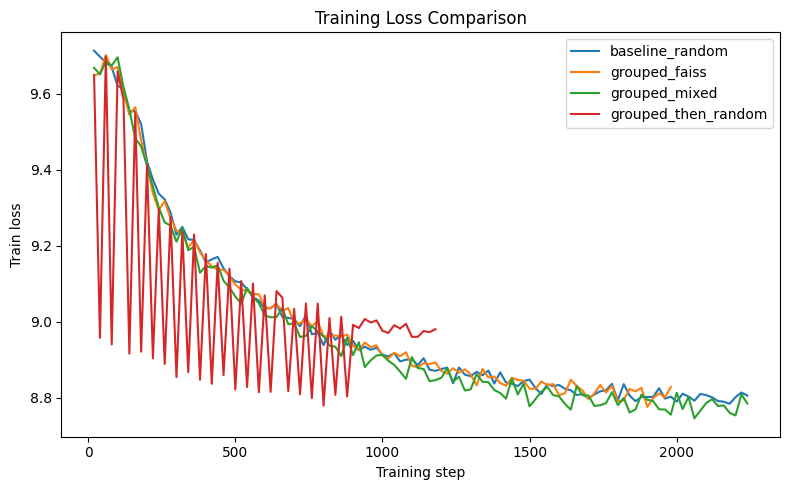

Wrote: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments/exp_005_eval_dashboard_dynamic/plots/figure_1_loss_comparison.png


In [47]:
# --- 11) Plot Figure-1: training loss comparison ---
plt.figure(figsize=(8, 5))

for run_name, run_info in runs.items():
    loss_df = run_info['loss_df']
    if loss_df.empty:
        continue
    plt.plot(loss_df['step'], loss_df['loss'], label=run_name)

plt.xlabel('Training step')
plt.ylabel('Train loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.tight_layout()

loss_cmp_path = f'{OUT_PLOTS}/figure_1_loss_comparison.png'
plt.savefig(loss_cmp_path, dpi=160)
plt.show()

print('Wrote:', loss_cmp_path)


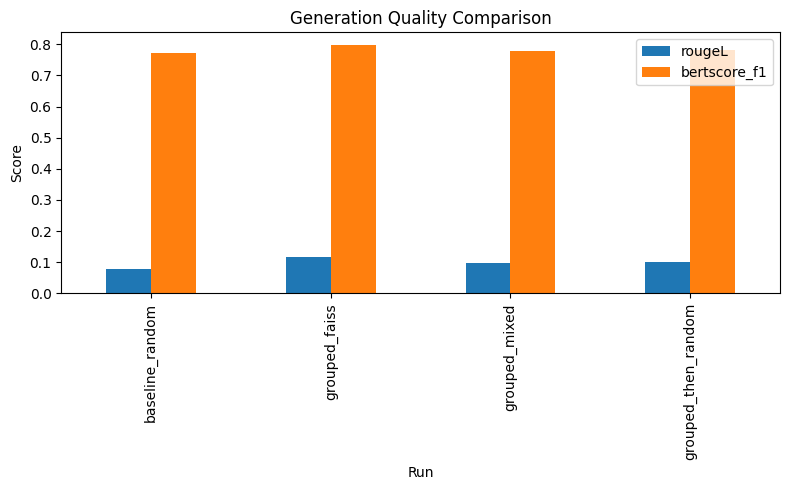

Wrote: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments/exp_005_eval_dashboard_dynamic/plots/figure_2_generation_metrics.png


In [48]:
# --- 12) Plot Figure-2: main generation metrics ---
plot_df = quality_df.set_index('run')[['rougeL', 'bertscore_f1']]
ax = plot_df.plot(kind='bar', figsize=(8, 5))
ax.set_title('Generation Quality Comparison')
ax.set_xlabel('Run')
ax.set_ylabel('Score')
ax.legend(loc='best')
plt.tight_layout()

quality_plot_path = f'{OUT_PLOTS}/figure_2_generation_metrics.png'
plt.savefig(quality_plot_path, dpi=160)
plt.show()

print('Wrote:', quality_plot_path)


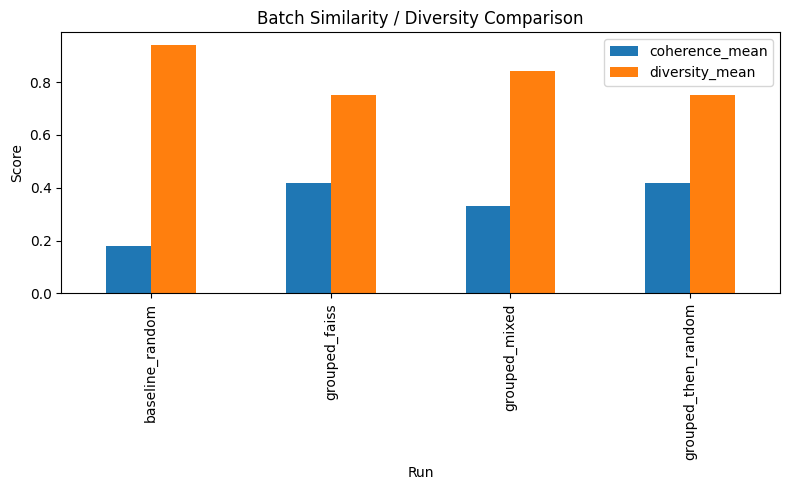

Wrote: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments/exp_005_eval_dashboard_dynamic/plots/figure_3_batch_metrics.png


In [49]:
# --- 13) Plot Figure-3: retrieval/grouping metrics ---
plot_df = batch_metrics_df.set_index('run')[['coherence_mean', 'diversity_mean']]
ax = plot_df.plot(kind='bar', figsize=(8, 5))
ax.set_title('Batch Similarity / Diversity Comparison')
ax.set_xlabel('Run')
ax.set_ylabel('Score')
ax.legend(loc='best')
plt.tight_layout()

retrieval_plot_path = f'{OUT_PLOTS}/figure_3_batch_metrics.png'
plt.savefig(retrieval_plot_path, dpi=160)
plt.show()

print('Wrote:', retrieval_plot_path)


In [50]:
# --- 14) Write machine-readable evaluation manifest ---
eval_manifest = {
    'eval_exp_id': EVAL_EXP_ID,
    'experiment_ids': [runs[k]['exp_id'] for k in runs],
    'run_names': list(runs.keys()),
    'labels': {k: runs[k]['label'] for k in runs},
    'dataset_name': DATASET_NAME,
    'base_model': BASE_MODEL_DIRNAME,
    'eval_samples': len(eval_ds),
    'paths': {
        'comparison_csv': comparison_csv,
        'quality_csv': quality_csv_path,
        'batch_metrics_csv': batch_metrics_csv_path,
        'phase_batch_metrics_csv': phase_batch_metrics_csv_path,
        'predictions_csv': predictions_csv_path,
        'qual_examples_csv': examples_path,
        'loss_comparison_plot': loss_cmp_path,
        'generation_plot': quality_plot_path,
        'batch_metrics_plot': retrieval_plot_path,
    }
}

manifest_path = f'{OUT_LOGS}/eval_manifest.json'
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(eval_manifest, f, indent=2)

print('Wrote:', manifest_path)
print('Wrote:', comparison_csv)


Wrote: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments/exp_005_eval_dashboard_dynamic/logs/eval_manifest.json
Wrote: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments/exp_005_eval_dashboard_dynamic/tables/experiment_comparison_table.csv


In [51]:
# --- 15) Rebuild / merge clean experiment_logs.csv from current summaries + recomputed eval ---
def _build_clean_experiment_log_rows():
    rows = []

    for run_name, run_info in runs.items():
        summary = run_info['summary']
        dyn = run_info['dyn']

        comp_row = comparison_df[comparison_df['run'] == run_name].iloc[0].to_dict()
        batch_row = batch_metrics_df[batch_metrics_df['run'] == run_name].iloc[0].to_dict()

        phases = run_info.get('phase_specs', [])
        phase1 = phases[0] if len(phases) > 0 else {}
        phase2 = phases[1] if len(phases) > 1 else {}

        phase1_metrics = phase_batch_metrics_df[
            (phase_batch_metrics_df['run'] == run_name) &
            (phase_batch_metrics_df['phase_name'] == phase1.get('phase_name'))
        ]
        phase2_metrics = phase_batch_metrics_df[
            (phase_batch_metrics_df['run'] == run_name) &
            (phase_batch_metrics_df['phase_name'] == phase2.get('phase_name'))
        ]

        row = {
            'exp_id': run_info['exp_id'],
            'date_utc': _summary_field(summary, 'created_at_utc', default=None),
            'model': _summary_field(summary, 'base_model', default=BASE_MODEL_DIRNAME),
            'dataset': _summary_field(summary, 'dataset_name', default=DATASET_NAME),
            'method': _summary_field(summary, 'method', default=run_name),
            'batch_size': _summary_field(summary, 'hparams', 'per_device_batch', default=PER_DEVICE_BATCH),
            'grad_accum': _summary_field(summary, 'hparams', 'grad_accum', default=None),
            'lr': _summary_field(summary, 'hparams', 'lr', default=None),
            'epochs': _summary_field(summary, 'hparams', 'epochs', default=None),
            'seed': _summary_field(summary, 'seed', default=SEED),
            'created_at_utc': _summary_field(summary, 'created_at_utc', default=None),
            'dataset_name': _summary_field(summary, 'dataset_name', default=DATASET_NAME),
            'base_model': _summary_field(summary, 'base_model', default=BASE_MODEL_DIRNAME),
            'sampler_mode': _summary_field(summary, 'batching', 'sampler_mode', default=batch_row.get('mode_used')),
            'grouped_fraction': _summary_field(summary, 'batching', 'grouped_fraction', default=batch_row.get('grouped_fraction')),
            'final_train_loss': dyn['final_train_loss'],
            'final_eval_loss': dyn['eval_loss'],
            'generalization_gap': dyn['generalization_gap'],
            'loss_variance': dyn['loss_variance'],
            'loss_std': dyn['loss_std'],
            'convergence_step_90pct': dyn['convergence_step_90pct'],
            'rouge1': comp_row.get('rouge1'),
            'rouge2': comp_row.get('rouge2'),
            'rougeL': comp_row.get('rougeL'),
            'rougeLsum': comp_row.get('rougeLsum'),
            'bertscore_precision': comp_row.get('bertscore_precision'),
            'bertscore_recall': comp_row.get('bertscore_recall'),
            'bertscore_f1': comp_row.get('bertscore_f1'),
            'coherence_mean': batch_row.get('coherence_mean'),
            'coherence_std': batch_row.get('coherence_std'),
            'diversity_mean': batch_row.get('diversity_mean'),
            'diversity_std': batch_row.get('diversity_std'),
            'phase_1_sampler_mode': phase1.get('sampler_mode'),
            'phase_1_epochs': phase1.get('epochs'),
            'phase_2_sampler_mode': phase2.get('sampler_mode'),
            'phase_2_epochs': phase2.get('epochs'),
            'phase_1_coherence_mean': phase1_metrics['coherence_mean'].iloc[0] if not phase1_metrics.empty else None,
            'phase_2_coherence_mean': phase2_metrics['coherence_mean'].iloc[0] if not phase2_metrics.empty else None,
            'run_root': run_info['obj']['run_root'],
        }

        rows.append(row)

    return pd.DataFrame(rows)

clean_log_df = _build_clean_experiment_log_rows()

if REBUILD_EXPERIMENT_LOG_CSV:
    if MERGE_WITH_EXISTING_EXPERIMENT_LOG and os.path.exists(EXPERIMENT_LOG_CSV_PATH):
        existing_df = pd.read_csv(EXPERIMENT_LOG_CSV_PATH)
        existing_df = existing_df[~existing_df['exp_id'].isin(clean_log_df['exp_id'])]
        final_log_df = pd.concat([existing_df, clean_log_df], ignore_index=True, sort=False)
    else:
        final_log_df = clean_log_df.copy()

    final_log_df = final_log_df.sort_values('exp_id').reset_index(drop=True)
    final_log_df.to_csv(EXPERIMENT_LOG_CSV_PATH, index=False)
    print('Updated experiment log at:', EXPERIMENT_LOG_CSV_PATH)
    display(final_log_df[final_log_df['exp_id'].isin(clean_log_df['exp_id'])])
else:
    display(clean_log_df)


Updated experiment log at: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments/experiment_logs/experiment_logs.csv


,exp_id,date_utc,model,dataset,method,batch_size,grad_accum,lr,epochs,seed,...,coherence_std,diversity_mean,diversity_std,phase_1_sampler_mode,phase_1_epochs,phase_2_sampler_mode,phase_2_epochs,phase_1_coherence_mean,phase_2_coherence_mean,run_root
0,exp_003_baseline_random_lora,None,flan-t5-small,dolly_small_1k,random_lora,8.0,None,None,None,42.0,...,0.031507,0.941515,0.021207,NaN,NaN,NaN,NaN,NaN,NaN,/content/drive/MyDrive/Compass_AI_ML_Research/...
1,exp_004_grouped_lora,None,flan-t5-small,dolly_small_1k,grouped_lora,8.0,None,None,None,42.0,...,0.083872,0.750963,0.100655,NaN,NaN,NaN,NaN,NaN,NaN,/content/drive/MyDrive/Compass_AI_ML_Research/...
2,exp_006_grouped_mixed_lora,None,flan-t5-small,dolly_small_1k,grouped_mixed_lora,8.0,None,None,None,42.0,...,0.089354,0.840515,0.074303,NaN,NaN,NaN,NaN,NaN,NaN,/content/drive/MyDrive/Compass_AI_ML_Research/...
3,exp_007_grouped_then_random_lora,None,flan-t5-small,dolly_small_1k,grouped_then_random_lora,8.0,None,None,None,42.0,...,0.083872,0.750963,0.100655,grouped,12.0,random,8.0,0.417417,0.17962,/content/drive/MyDrive/Compass_AI_ML_Research/...



## Recommended next step after this notebook

Run the exact same pipeline for multiple seeds:
- seed = 42
- seed = 43
- seed = 44

Then aggregate all runs into a **mean ± std** table. That will make your thesis claims much stronger and protect against the “this might just be randomness” objection.
